# 03 · Estilo de juego: clustering

**Objetivo:** agrupar a los equipos según **cómo juegan**, no según lo buenos que son, y construir un **catálogo de estilos** que la fase 4 pueda usar sin fuga de información.

**Decisiones de esta fase**

| Decisión | Elección | Motivo |
|---|---|---|
| Unidad de observación | Equipo-temporada (2014/15–2025/26, 240 observaciones) | Estable (38 partidos) e interpretable |
| Variables | PPDA, PPDA del rival, pases profundos, xG por tiro, xG por tiro en contra, faltas | Una por dimensión del juego; se excluyen las de volumen (tiros, córners), que miden sobre todo calidad |
| Estilo frente a calidad | Se descuenta la parte de cada variable que explica el Elo medio de la temporada (residuos) | Casi todas las variables están muy ligadas a la calidad |
| Efecto de la época | Estandarización dentro de cada temporada | La liga presiona menos y comete menos faltas que hace 10 años; sin corregir, los grupos serían épocas |
| Escalado | Incluido en la estandarización | El clustering mide distancias: sin escalar, el PPDA dominaría |
| Peso de cada variable | Se reestandarizan los residuos (todas pesan igual) | Lo que queda tras descontar la calidad es estilo fiable, no ruido (sección 4) |
| Algoritmo | k-means | Sus centros son directamente el catálogo que usará la fase 4 |
| Número de estilos | Codo + silueta + estabilidad (100 remuestreos), con k de 2 a 8 | La silueta y el codo miden separación; la estabilidad, si los grupos son reproducibles |
| Resultado | k = 3; los estilos son un continuo (silueta ≈ 0,17, apenas por encima de datos sin estructura; estabilidad 0,61 < 0,75) | Ver sección 5 |
| Uso de los estilos | Los 3 estilos **para comunicar**; las **coordenadas continuas** (6 variables de estilo) **para el modelo** de la fase 4 | Con grupos poco separados, una etiqueta pierde información y cambia por ruido en la frontera |
| PCA | Solo para el mapa 2D, no para el clustering | Con 6 variables poco redundantes, los grupos se interpretan mejor con las variables originales |
| Uso en la fase 4 | Ventana móvil previa a cada partido, comparada con el catálogo (construido solo con temporadas de entrenamiento) | Sin fuga de información |

**Limitación:** no hay datos de **posesión** en ninguna fuente. El PPDA del rival es la mejor aproximación.

## 0. Preparación

In [1]:
from pathlib import Path

import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = Path.cwd().parent
PROCESSED = ROOT / "data" / "processed"
FIGURES = ROOT / "reports" / "figures"

con = duckdb.connect()
for tabla in ("partidos_equipo", "forma_elo"):
    con.sql(f"CREATE VIEW {tabla} AS SELECT * FROM read_csv('{(PROCESSED / f'{tabla}.csv').as_posix()}')")

SERIE, TINTA, TINTA_2, FONDO, REJILLA = "#2a78d6", "#0b0b0b", "#52514e", "#fcfcfb", "#e4e3df"

## 1. Variables por equipo-temporada

Los ratios se calculan como **cociente de sumas**, no como media de cocientes (la lección del PPDA en la fase 1): PPDA = suma de pases ÷ suma de acciones; xG por tiro = suma de xG ÷ suma de tiros.

La calidad se mide con el **Elo medio del equipo en la temporada** (media de su Elo antes de cada partido). Para el catálogo, que es descriptivo, eso está bien; en la fase 4 se usará el Elo previo a cada partido.

In [2]:
VARIABLES = {
    "ppda": "PPDA (bajo = más presión)",
    "ppda_rival": "PPDA del rival (alto = te dejan jugar)",
    "profundos_pp": "Pases profundos por partido",
    "xg_por_tiro": "xG por tiro",
    "xg_por_tiro_contra": "xG por tiro en contra",
    "faltas_pp": "Faltas por partido",
}

et = con.sql("""
SELECT pe.temporada, pe.equipo,
       count(*)                                          AS partidos,
       avg(pe.puntos)                                    AS puntos_pp,
       avg(fe.elo_antes)                                 AS elo_medio,
       sum(pe.ppda_pases) / sum(pe.ppda_acciones)        AS ppda,
       sum(pe.ppda_pases_rival) / sum(pe.ppda_acciones_rival) AS ppda_rival,
       avg(pe.pases_profundos_favor)                     AS profundos_pp,
       sum(pe.xg_favor) / sum(pe.tiros_favor)            AS xg_por_tiro,
       sum(pe.xg_contra) / sum(pe.tiros_contra)          AS xg_por_tiro_contra,
       avg(pe.faltas_cometidas)                          AS faltas_pp
FROM partidos_equipo pe
JOIN forma_elo fe USING (id_partido, equipo)
WHERE pe.temporada >= '2014-15'
GROUP BY pe.temporada, pe.equipo
ORDER BY pe.temporada, pe.equipo
""").df()

assert len(et) == 240 and (et.partidos == 38).all() and et[list(VARIABLES)].notna().all().all()
et[["temporada", "equipo", "elo_medio", *VARIABLES]].head()

,temporada,equipo,elo_medio,ppda,ppda_rival,profundos_pp,xg_por_tiro,xg_por_tiro_contra,faltas_pp
0,2014-15,Almería,1383.030503,8.227498,5.912867,3.578947,0.097899,0.109215,14.789474
1,2014-15,Athletic Club,1542.973530,7.258772,8.746849,4.815789,0.103270,0.115161,13.921053
2,2014-15,Atlético de Madrid,1701.215139,8.269737,8.443956,5.184211,0.130246,0.088625,14.289474
3,2014-15,Barcelona,1772.263265,5.561866,13.859244,12.868421,0.164505,0.093260,9.710526
4,2014-15,Celta de Vigo,1488.048330,5.927614,10.272000,7.552632,0.118724,0.122695,15.421053


## 2. Estandarización dentro de cada temporada

Cada valor se expresa como **cuántas desviaciones típicas se aleja de la media de la liga en esa temporada**:

$$z = \frac{\text{valor} - \text{media de la temporada}}{\text{desviación típica de la temporada}}$$

Así, "presiona mucho" significa "más que sus rivales de ese año", y todas las variables quedan en la misma escala. El Elo medio también se estandariza por temporada.

In [3]:
columnas_z = [*VARIABLES, "elo_medio"]
por_temporada = et.groupby("temporada")[columnas_z]
z = (et[columnas_z] - por_temporada.transform("mean")) / por_temporada.transform("std")

comprobacion = z.groupby(et.temporada).agg(["mean", "std"]).round(6)
assert np.allclose(comprobacion.xs("mean", axis=1, level=1), 0)
assert np.allclose(comprobacion.xs("std", axis=1, level=1), 1)
print("En cada temporada, todas las variables tienen media 0 y desviación típica 1.")

En cada temporada, todas las variables tienen media 0 y desviación típica 1.


In [4]:
# Efecto de la estandarización sobre la tendencia de la época: media de la liga por temporada
pd.DataFrame({"PPDA medio (bruto)": et.groupby("temporada").ppda.mean().round(2),
              "Faltas por partido (bruto)": et.groupby("temporada").faltas_pp.mean().round(2),
              "PPDA medio (estandarizado)": z.groupby(et.temporada).ppda.mean().round(2)}).T

temporada,2014-15,2015-16,2016-17,2017-18,2018-19,2019-20,2020-21,2021-22,2022-23,2023-24,2024-25,2025-26
PPDA medio (bruto),8.29,8.31,8.89,9.44,9.53,9.71,10.31,10.13,10.67,11.25,11.41,11.12
Faltas por partido (bruto),14.22,13.60,13.94,13.84,13.54,13.73,13.25,13.22,12.95,12.93,12.37,12.58
PPDA medio (estandarizado),0.00,0.00,0.00,-0.00,0.00,-0.00,0.00,-0.00,-0.00,0.00,0.00,0.00


## 3. Descontar la calidad

Para cada variable ajustamos una **regresión lineal** sobre el Elo (las dos ya estandarizadas):

$$z_{\text{variable}} = a + b \cdot z_{\text{Elo}} + \text{residuo}$$

- $a + b \cdot z_{\text{Elo}}$ es lo que **se esperaría de un equipo de ese nivel**.
- El **residuo** es el estilo: cuánto se aparta el equipo de lo esperado para su calidad. Un residuo de +1 en pases profundos significa "llega mucho más de lo que corresponde a su nivel".

Comprobamos el efecto comparando la correlación de cada variable con el Elo antes y después.

In [5]:
residuos = pd.DataFrame(index=et.index)
pendientes = {}
for variable in VARIABLES:
    b, a = np.polyfit(z.elo_medio, z[variable], deg=1)
    residuos[variable] = z[variable] - (a + b * z.elo_medio)
    pendientes[variable] = b

efecto = pd.DataFrame({
    "variable": list(VARIABLES.values()),
    "correlación con Elo (antes)": [z[v].corr(z.elo_medio) for v in VARIABLES],
    "correlación con Elo (después)": [residuos[v].corr(z.elo_medio) for v in VARIABLES],
    "correlación con puntos (antes)": [et[v].corr(et.puntos_pp) for v in VARIABLES],
    "correlación con puntos (después)": [residuos[v].corr(et.puntos_pp) for v in VARIABLES],
    "desviación típica del residuo": [residuos[v].std() for v in VARIABLES],
}).round(2)
assert (efecto["correlación con Elo (después)"].abs() < 1e-9).all()
efecto

,variable,correlación con Elo (antes),correlación con Elo (después),correlación con puntos (antes),correlación con puntos (después),desviación típica del residuo
0,PPDA (bajo = más presión),-0.32,0.0,-0.25,-0.00,0.93
1,PPDA del rival (alto = te dejan jugar),0.78,-0.0,0.63,-0.02,0.61
2,Pases profundos por partido,0.87,0.0,0.81,0.02,0.49
3,xG por tiro,0.71,-0.0,0.72,0.11,0.69
4,xG por tiro en contra,-0.48,0.0,-0.50,-0.08,0.86
5,Faltas por partido,-0.53,0.0,-0.45,0.02,0.83


Por construcción, los residuos no tienen correlación con el Elo. La correlación con los **puntos** también baja mucho, aunque no desaparece del todo: el Elo mide la calidad bien, pero no perfectamente.

La última columna es importante para el siguiente paso: las variables muy ligadas a la calidad (p. ej. pases profundos) conservan **poca variación** tras descontarla. Si no se reescalan, pesarán menos en el clustering.

In [6]:
# ¿Son redundantes las 6 variables de estilo? (correlaciones entre residuos)
residuos.rename(columns=VARIABLES).corr().round(2)

,PPDA (bajo = más presión),PPDA del rival (alto = te dejan jugar),Pases profundos por partido,xG por tiro,xG por tiro en contra,Faltas por partido
PPDA (bajo = más presión),1.00,-0.25,-0.21,0.10,-0.32,-0.33
PPDA del rival (alto = te dejan jugar),-0.25,1.00,0.48,0.05,0.23,-0.49
Pases profundos por partido,-0.21,0.48,1.00,0.38,0.21,-0.32
xG por tiro,0.10,0.05,0.38,1.00,-0.14,-0.06
xG por tiro en contra,-0.32,0.23,0.21,-0.14,1.00,-0.10
Faltas por partido,-0.33,-0.49,-0.32,-0.06,-0.10,1.00


## 4. ¿Reescalar los residuos? Fiabilidad por mitades

Tras descontar la calidad, algunas variables conservan poca variación (pases profundos: 0,49). ¿Es estilo real en escala pequeña, o ruido?

**Fiabilidad por mitades:** calculamos cada variable por separado en la primera y la segunda vuelta de cada temporada (con el mismo proceso: estandarizar por temporada y descontar el Elo). Si un equipo que destaca en la primera vuelta también destaca en la segunda, la variable mide algo **estable del equipo**. La correlación entre mitades se corrige con la fórmula de **Spearman-Brown** para estimar la fiabilidad con la temporada completa (38 partidos):

$$\text{fiabilidad}_{38} = \frac{2r}{1 + r}$$

In [7]:
mitades = con.sql("""
WITH numerados AS (
    SELECT pe.*, fe.elo_antes,
           row_number() OVER (PARTITION BY pe.temporada, pe.equipo ORDER BY pe.fecha, pe.id_partido) AS n
    FROM partidos_equipo pe JOIN forma_elo fe USING (id_partido, equipo)
    WHERE pe.temporada >= '2014-15'
)
SELECT temporada, equipo, CASE WHEN n <= 19 THEN 1 ELSE 2 END AS mitad,
       avg(elo_antes)                                     AS elo_medio,
       sum(ppda_pases) / sum(ppda_acciones)               AS ppda,
       sum(ppda_pases_rival) / sum(ppda_acciones_rival)   AS ppda_rival,
       avg(pases_profundos_favor)                         AS profundos_pp,
       sum(xg_favor) / sum(tiros_favor)                   AS xg_por_tiro,
       sum(xg_contra) / sum(tiros_contra)                 AS xg_por_tiro_contra,
       avg(faltas_cometidas)                              AS faltas_pp
FROM numerados
GROUP BY temporada, equipo, mitad
""").df()


def residuos_estilo(df):
    """Estandariza por temporada y descuenta la parte explicada por el Elo medio."""
    g = df.groupby("temporada")[[*VARIABLES, "elo_medio"]]
    zz = (df[[*VARIABLES, "elo_medio"]] - g.transform("mean")) / g.transform("std")
    salida = pd.DataFrame(index=df.index)
    for v in VARIABLES:
        b, a = np.polyfit(zz.elo_medio, zz[v], deg=1)
        salida[v] = zz[v] - (a + b * zz.elo_medio)
    return salida


por_mitad = {m: residuos_estilo(d.set_index(["temporada", "equipo"])) for m, d in mitades.groupby("mitad")}
r1, r2 = por_mitad[1].align(por_mitad[2], join="inner")
r = pd.Series({v: r1[v].corr(r2[v]) for v in VARIABLES})
pd.DataFrame({"variable": list(VARIABLES.values()),
              "variación que conserva": [residuos[v].std() for v in VARIABLES],
              "correlación 1ª-2ª vuelta": r.values,
              "fiabilidad (38 partidos)": (2 * r / (1 + r)).values}).round(2)

,variable,variación que conserva,correlación 1ª-2ª vuelta,fiabilidad (38 partidos)
0,PPDA (bajo = más presión),0.93,0.66,0.79
1,PPDA del rival (alto = te dejan jugar),0.61,0.65,0.79
2,Pases profundos por partido,0.49,0.64,0.78
3,xG por tiro,0.69,0.37,0.54
4,xG por tiro en contra,0.86,0.35,0.52
5,Faltas por partido,0.83,0.65,0.79


- **Los pases profundos conservan poca variación, pero muy fiable (≈ 0,78):** es estilo real en escala pequeña, no ruido. Sin reescalar, perdería peso una dimensión auténtica del juego.
- **Las dos variables de xG por tiro son las menos fiables (≈ 0,53):** la mitad de lo que miden es azar. Al interpretar los grupos, desconfiaremos de un estilo que se distinga *solo* por ellas.

**Decisión:** se reestandarizan los residuos (desviación típica 1), de modo que las 6 dimensiones pesan igual. Las diferencias de variación reflejaban cuánto se parecía cada variable a la calidad, no cuánto importa como dimensión del estilo.

In [8]:
X_df = (residuos - residuos.mean()) / residuos.std()
X = X_df.to_numpy()
X_df.std().round(3).to_frame("desviación típica").T

,ppda,ppda_rival,profundos_pp,xg_por_tiro,xg_por_tiro_contra,faltas_pp
desviación típica,1.0,1.0,1.0,1.0,1.0,1.0


## 5. ¿Cuántos estilos?

Probamos k-means con k de 2 a 8 y medimos tres cosas:

| Criterio | Qué mide | Cómo se lee |
|---|---|---|
| **Inercia (codo)** | Suma de distancias al cuadrado de cada equipo a su centro | Siempre baja al aumentar k; se busca el punto donde deja de bajar mucho |
| **Silueta** | Para cada equipo, si se parece más a su grupo que al grupo vecino (de −1 a 1) | Más alto = grupos mejor separados |
| **Estabilidad** | Se repite el clustering con 100 remuestreos *bootstrap* de los 240 equipos-temporada y se compara con el original mediante el **índice de Rand ajustado** (ARI) | 1 = mismos grupos siempre; 0 = como asignar al azar. Por encima de ~0,75 se considera estable |

**Referencia sin estructura:** la silueta que obtiene k-means en datos donde cada columna se ha barajado por separado (se conservan las distribuciones, pero se destruye cualquier agrupación real). Nuestra silueta tiene que superarla para que los grupos signifiquen algo.

k-means se ejecuta con 50 inicios distintos (`n_init`) y se queda con el mejor: su resultado depende del punto de partida.

In [9]:
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, silhouette_score

rng = np.random.default_rng(42)
N_REMUESTREOS = 100
resultados = []
for k in range(2, 9):
    referencia = KMeans(n_clusters=k, n_init=50, random_state=0).fit(X)

    aleatorias = []
    for i in range(20):
        barajado = np.column_stack([rng.permutation(col) for col in X.T])
        etiquetas = KMeans(n_clusters=k, n_init=10, random_state=i).fit_predict(barajado)
        aleatorias.append(silhouette_score(barajado, etiquetas))

    ari = []
    for i in range(N_REMUESTREOS):
        muestra = rng.integers(0, len(X), len(X))
        modelo = KMeans(n_clusters=k, n_init=10, random_state=i).fit(X[muestra])
        ari.append(adjusted_rand_score(referencia.labels_, modelo.predict(X)))

    resultados.append({"k": k, "inercia": referencia.inertia_,
                       "silueta": silhouette_score(X, referencia.labels_),
                       "silueta_sin_estructura": np.mean(aleatorias),
                       "estabilidad_ari": np.mean(ari),
                       "estabilidad_ari_p10": np.percentile(ari, 10),
                       "tamaño_grupos": sorted(np.bincount(referencia.labels_).tolist(), reverse=True)})

eleccion_k = pd.DataFrame(resultados)
eleccion_k.round(3)

,k,inercia,silueta,silueta_sin_estructura,estabilidad_ari,estabilidad_ari_p10,tamaño_grupos
0,2,1143.149,0.178,0.128,0.520,0.279,"[137, 103]"
1,3,968.531,0.169,0.123,0.612,0.237,"[90, 90, 60]"
2,4,860.667,0.162,0.128,0.545,0.328,"[72, 72, 50, 46]"
3,5,795.260,0.168,0.130,0.500,0.341,"[71, 70, 49, 38, 12]"
4,6,731.412,0.173,0.130,0.457,0.326,"[74, 56, 34, 32, 31, 13]"
5,7,679.822,0.162,0.132,0.448,0.323,"[61, 47, 38, 33, 28, 24, 9]"
6,8,636.779,0.165,0.136,0.439,0.349,"[53, 41, 34, 29, 29, 25, 19, 10]"


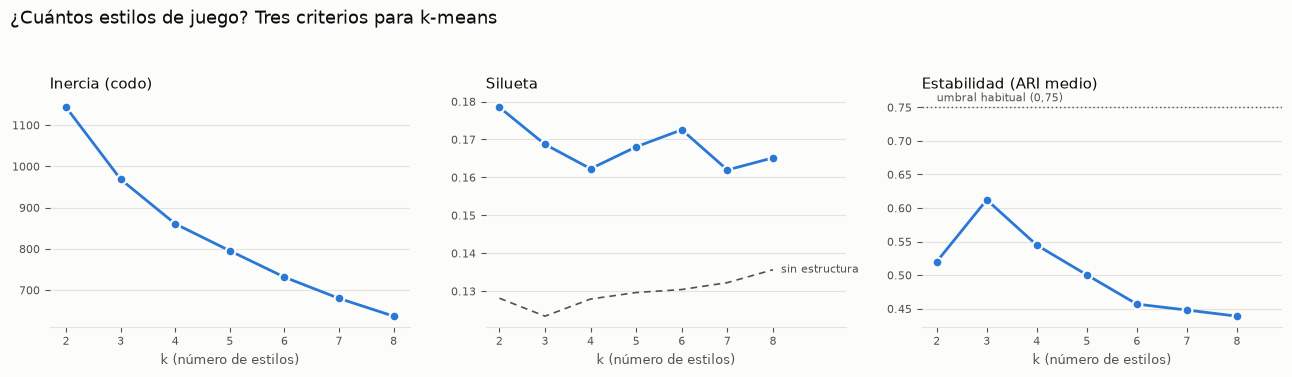

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.8), facecolor=FONDO)
paneles = (("inercia", "Inercia (codo)", None),
           ("silueta", "Silueta", "silueta_sin_estructura"),
           ("estabilidad_ari", "Estabilidad (ARI medio)", None))
for ax, (col, titulo, referencia_col) in zip(axes, paneles):
    ax.plot(eleccion_k.k, eleccion_k[col], color=SERIE, linewidth=2, marker="o", markersize=7,
            markeredgecolor=FONDO, markeredgewidth=1.5, zorder=3)
    if referencia_col:
        ax.plot(eleccion_k.k, eleccion_k[referencia_col], color=TINTA_2, linewidth=1.2,
                linestyle=(0, (4, 3)), zorder=2)
        ax.text(eleccion_k.k.iloc[-1], eleccion_k[referencia_col].iloc[-1], "  sin estructura",
                fontsize=8, color=TINTA_2, va="center")
    if col == "estabilidad_ari":
        ax.axhline(0.75, color=TINTA_2, linewidth=1, linestyle=(0, (1, 2)))
        ax.text(2, 0.755, "umbral habitual (0,75)", fontsize=8, color=TINTA_2, va="bottom")
    ax.set_title(titulo, loc="left", fontsize=11, color=TINTA)
    ax.set_xticks(eleccion_k.k)
    ax.set_xlabel("k (número de estilos)", color=TINTA_2, fontsize=9)
    ax.set_facecolor(FONDO)
    ax.grid(axis="y", color=REJILLA, linewidth=0.8)
    ax.set_axisbelow(True)
    ax.tick_params(colors=TINTA_2, labelsize=8)
    for lado in ("top", "right", "left"):
        ax.spines[lado].set_visible(False)
    ax.spines["bottom"].set_color(REJILLA)
axes[2].set_xlim(1.7, 8.9)
axes[1].set_xlim(1.7, 9.6)
fig.suptitle("¿Cuántos estilos de juego? Tres criterios para k-means", x=0.01, ha="left", fontsize=13, color=TINTA)
fig.tight_layout(rect=(0, 0, 1, 0.93))
fig.savefig(FIGURES / "03_eleccion_k.png", dpi=150, facecolor=FONDO)
plt.show()

**Lectura de los tres criterios:**

- **Codo:** la inercia baja de forma suave, sin un codo claro (como mucho, un ligero cambio en k = 3).
- **Silueta:** 0,16–0,18, solo unos 0,04 por encima de la referencia sin estructura.
- **Estabilidad:** máxima en k = 3 (0,61), pero ningún k llega al umbral de 0,75.

**Conclusión: los estilos de LaLiga son un continuo**, no familias separadas. Elegimos **k = 3** (el más estable y con perfiles interpretables) como **resumen para comunicar**; en el modelo de la fase 4 se usarán las **coordenadas continuas**.

## 6. El catálogo: tres estilos

k-means numera los grupos de forma arbitraria (el "grupo 0" puede cambiar al re-ejecutar). Por eso los nombres se asignan **por el perfil**, no por el número:

- El grupo que **más presiona** (PPDA más bajo) → **Presión alta y posesión**.
- El grupo con **más faltas** → **Directo y físico**.
- El restante → **Bloque medio y juego limpio**.

Los valores del perfil son desviaciones típicas respecto a lo que se esperaría de un equipo **de ese nivel y en esa temporada**.

In [11]:
K = 3
kmeans = KMeans(n_clusters=K, n_init=50, random_state=0).fit(X)
centros = pd.DataFrame(kmeans.cluster_centers_, columns=list(VARIABLES))

presion = centros.ppda.idxmin()
fisico = centros.drop(index=presion).faltas_pp.idxmax()
medio = ({0, 1, 2} - {presion, fisico}).pop()
NOMBRES = {presion: "Presión alta y posesión", medio: "Bloque medio y juego limpio", fisico: "Directo y físico"}
ORDEN = ["Presión alta y posesión", "Bloque medio y juego limpio", "Directo y físico"]

et["estilo"] = pd.Series(kmeans.labels_).map(NOMBRES).values
catalogo = centros.rename(index=NOMBRES).loc[ORDEN]
catalogo["equipos_temporada"] = et.estilo.value_counts().reindex(ORDEN).values
catalogo["elo_medio"] = et.groupby("estilo").elo_medio.mean().reindex(ORDEN).round(0).values
catalogo.round(2)

,ppda,ppda_rival,profundos_pp,xg_por_tiro,xg_por_tiro_contra,faltas_pp,equipos_temporada,elo_medio
Presión alta y posesión,-0.75,0.68,0.56,-0.02,0.64,-0.11,90,1509.0
Bloque medio y juego limpio,0.78,0.00,0.07,0.23,-0.37,-0.61,90,1490.0
Directo y físico,-0.05,-1.02,-0.95,-0.30,-0.41,1.08,60,1522.0


In [12]:
# Equipos más frecuentes en cada estilo (temporadas en ese estilo)
pd.DataFrame({estilo: et[et.estilo == estilo].equipo.value_counts().head(6)
              .map(lambda n: f"{n} temp.").reset_index().agg(lambda f: f"{f.equipo} ({f['count']})", axis=1).values
              for estilo in ORDEN})

,Presión alta y posesión,Bloque medio y juego limpio,Directo y físico
0,Barcelona (11 temp.),Real Madrid (9 temp.),Getafe (9 temp.)
1,Celta de Vigo (9 temp.),Villarreal (8 temp.),Atlético de Madrid (8 temp.)
2,Rayo Vallecano (7 temp.),Levante (6 temp.),Athletic Club (6 temp.)
3,Real Betis (7 temp.),Valencia (6 temp.),Valencia (5 temp.)
4,Eibar (6 temp.),Espanyol (5 temp.),Alavés (5 temp.)
5,Real Sociedad (6 temp.),Real Betis (4 temp.),Espanyol (4 temp.)


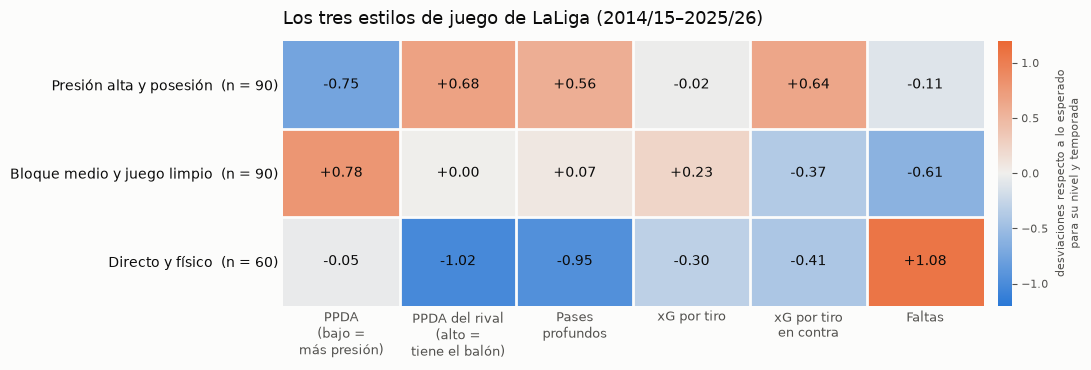

In [13]:
# Perfil de cada estilo: mapa de calor con escala divergente (negativo / 0 / positivo)
from matplotlib.colors import LinearSegmentedColormap

DIVERGENTE = LinearSegmentedColormap.from_list("div", ["#2a78d6", "#f0efec", "#eb6834"])
ETIQUETAS_CORTAS = {"ppda": "PPDA\n(bajo =\nmás presión)", "ppda_rival": "PPDA del rival\n(alto =\ntiene el balón)",
                    "profundos_pp": "Pases\nprofundos", "xg_por_tiro": "xG por tiro",
                    "xg_por_tiro_contra": "xG por tiro\nen contra", "faltas_pp": "Faltas"}

valores = catalogo[list(VARIABLES)]
fig, ax = plt.subplots(figsize=(11, 3.8), facecolor=FONDO)
im = ax.imshow(valores.to_numpy(), cmap=DIVERGENTE, vmin=-1.2, vmax=1.2, aspect="auto")
for (i, j), v in np.ndenumerate(valores.to_numpy()):
    ax.text(j, i, f"{v:+.2f}", ha="center", va="center", fontsize=10, color=TINTA)
ax.set_xticks(range(len(VARIABLES)), [ETIQUETAS_CORTAS[v] for v in VARIABLES], fontsize=9, color=TINTA_2)
ax.set_yticks(range(K), [f"{e}  (n = {n})" for e, n in zip(ORDEN, catalogo.equipos_temporada)], fontsize=10, color=TINTA)
ax.tick_params(length=0)
for pos in np.arange(0.5, len(VARIABLES) - 1, 1):
    ax.axvline(pos, color=FONDO, linewidth=2)
for pos in np.arange(0.5, K - 1, 1):
    ax.axhline(pos, color=FONDO, linewidth=2)
for lado in ax.spines.values():
    lado.set_visible(False)
barra = fig.colorbar(im, ax=ax, fraction=0.025, pad=0.02)
barra.outline.set_visible(False)
barra.ax.tick_params(labelsize=8, colors=TINTA_2)
barra.set_label("desviaciones respecto a lo esperado\npara su nivel y temporada", fontsize=8, color=TINTA_2)
ax.set_title("Los tres estilos de juego de LaLiga (2014/15–2025/26)", loc="left", fontsize=13, color=TINTA, pad=12)
fig.tight_layout()
fig.savefig(FIGURES / "03_perfiles_estilo.png", dpi=150, facecolor=FONDO)
plt.show()

## 7. Mapa de estilos (PCA) y evolución de equipos

El **PCA** resume las 6 variables en 2 ejes que recogen la mayor parte de la variación, para poder dibujar los 240 equipos-temporada en un plano. **Solo se usa para visualizar**: el clustering se hizo con las 6 variables.

Primero vemos qué representa cada eje (sus **cargas**: cuánto pesa cada variable en él).

In [14]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2).fit(X)
coordenadas = pca.transform(X)
et["pca_1"], et["pca_2"] = coordenadas[:, 0], coordenadas[:, 1]

cargas = pd.DataFrame(pca.components_.T, index=list(VARIABLES.values()),
                      columns=[f"eje {i + 1} ({100 * v:.0f} % de la varianza)" for i, v in enumerate(pca.explained_variance_ratio_)])
cargas.round(2)

,eje 1 (34 % de la varianza),eje 2 (25 % de la varianza)
PPDA (bajo = más presión),-0.19,0.68
PPDA del rival (alto = te dejan jugar),0.58,-0.03
Pases profundos por partido,0.56,0.06
xG por tiro,0.19,0.37
xG por tiro en contra,0.31,-0.46
Faltas por partido,-0.42,-0.44


**Cómo leer los ejes:**

- **Eje 1 (horizontal):** a la derecha, equipos que **tienen el balón y llegan** (PPDA del rival alto, muchos pases profundos) y cometen pocas faltas; a la izquierda, **juego directo y físico**.
- **Eje 2 (vertical):** arriba, equipos que **esperan sin presionar** (PPDA alto) y no conceden ocasiones claras; abajo, **presión alta**.

Los dos ejes recogen el 59 % de la variación: el mapa es una buena aproximación, pero no la foto completa.

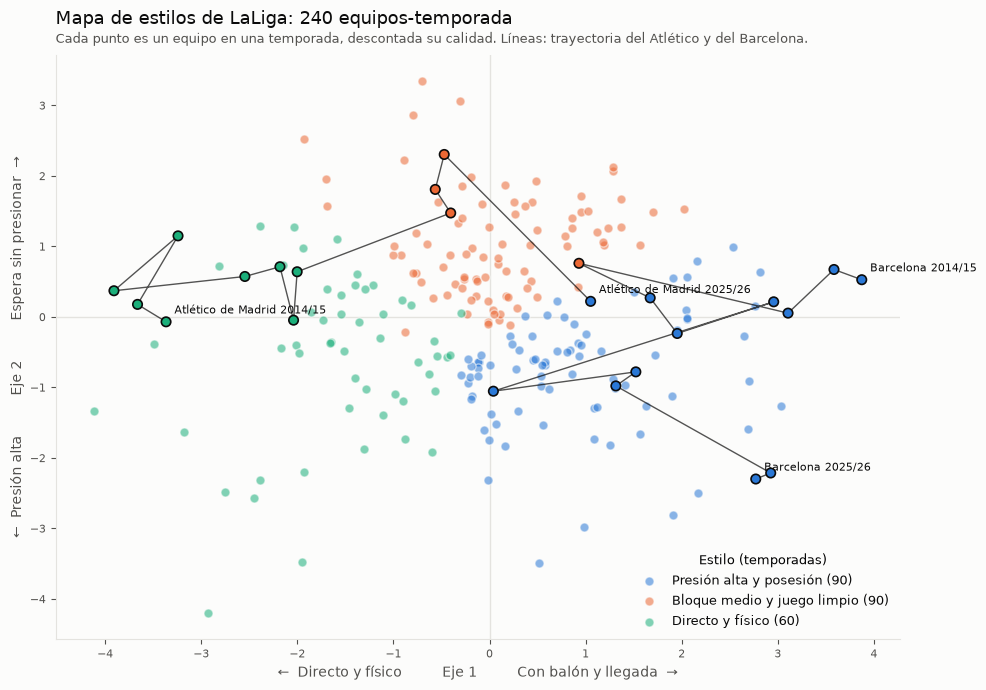

In [15]:
COLORES_ESTILO = dict(zip(ORDEN, ["#2a78d6", "#eb6834", "#1baf7a"]))   # paleta categórica, en orden fijo
TRAYECTORIAS = ["Atlético de Madrid", "Barcelona"]

fig, ax = plt.subplots(figsize=(10, 7), facecolor=FONDO)
for estilo in ORDEN:
    d = et[et.estilo == estilo]
    ax.scatter(d.pca_1, d.pca_2, s=42, color=COLORES_ESTILO[estilo], alpha=0.55,
               edgecolor=FONDO, linewidth=1, label=f"{estilo} ({len(d)})", zorder=2)

for equipo in TRAYECTORIAS:
    d = et[et.equipo == equipo].sort_values("temporada")
    ax.plot(d.pca_1, d.pca_2, color=TINTA, linewidth=1, alpha=0.7, zorder=3)
    ax.scatter(d.pca_1, d.pca_2, s=46, facecolor=[COLORES_ESTILO[e] for e in d.estilo],
               edgecolor=TINTA, linewidth=1.2, zorder=4)
    for _, fila in d.iloc[[0, -1]].iterrows():
        ax.annotate(f"{equipo} {fila.temporada.replace('-', '/')}", (fila.pca_1, fila.pca_2),
                    xytext=(6, 6), textcoords="offset points", fontsize=8, color=TINTA)

ax.axhline(0, color=REJILLA, linewidth=1, zorder=1)
ax.axvline(0, color=REJILLA, linewidth=1, zorder=1)
ax.set_xlabel("←  Directo y físico          Eje 1          Con balón y llegada  →", color=TINTA_2)
ax.set_ylabel("←  Presión alta          Eje 2          Espera sin presionar  →", color=TINTA_2)
ax.legend(loc="lower right", frameon=False, fontsize=9, labelcolor=TINTA, title="Estilo (temporadas)",
          title_fontsize=9)
ax.set_facecolor(FONDO)
ax.tick_params(colors=TINTA_2, labelsize=8)
for lado in ("top", "right"):
    ax.spines[lado].set_visible(False)
for lado in ("left", "bottom"):
    ax.spines[lado].set_color(REJILLA)
ax.set_title("Mapa de estilos de LaLiga: 240 equipos-temporada", loc="left", fontsize=13, color=TINTA, pad=22)
ax.text(0, 1.02, "Cada punto es un equipo en una temporada, descontada su calidad. "
        "Líneas: trayectoria del Atlético y del Barcelona.", transform=ax.transAxes, fontsize=9, color=TINTA_2)
fig.tight_layout()
fig.savefig(FIGURES / "03_mapa_estilos.png", dpi=150, facecolor=FONDO)
plt.show()

In [16]:
# Evolución del estilo de algunos equipos, temporada a temporada
(et[et.equipo.isin(["Barcelona", "Real Madrid", "Atlético de Madrid", "Getafe", "Athletic Club"])]
 .pivot(index="temporada", columns="equipo", values="estilo")
 .replace({"Presión alta y posesión": "Presión", "Bloque medio y juego limpio": "Bloque medio",
           "Directo y físico": "Directo"}))

equipo,Athletic Club,Atlético de Madrid,Barcelona,Getafe,Real Madrid
temporada,,,,,
2014-15,Presión,Directo,Presión,Bloque medio,Bloque medio
2015-16,Presión,Directo,Presión,Bloque medio,Bloque medio
2016-17,Presión,Directo,Presión,NaN,Bloque medio
2017-18,Directo,Directo,Bloque medio,Directo,Presión
2018-19,Presión,Directo,Presión,Directo,Presión
2019-20,Directo,Directo,Presión,Directo,Presión
2020-21,Bloque medio,Directo,Presión,Directo,Bloque medio
2021-22,Bloque medio,Directo,Presión,Directo,Bloque medio
2022-23,Directo,Bloque medio,Presión,Directo,Bloque medio


## 8. Exportación

| Fichero | Contenido | ¿En Git? |
|---|---|---|
| `estilos_equipo_temporada.csv` | Un equipo-temporada por fila: estilo, variables originales, coordenadas de estilo (las 6 variables tras estandarizar y descontar la calidad) y ejes del PCA | No (derivado de Understat) |
| `estilos_catalogo.csv` | El perfil de cada estilo (centros de k-means) | Sí |

⚠️ **Este catálogo es descriptivo** (usa las 12 temporadas). En la fase 4, el catálogo y las coordenadas se recalcularán **solo con las temporadas de entrenamiento**, y cada partido recibirá su estilo a partir de una **ventana de partidos anteriores**, para evitar la fuga de información.

In [17]:
COORDENADAS = {v: f"estilo_{v}" for v in VARIABLES}
salida = pd.concat([et[["temporada", "equipo", "estilo", "elo_medio", "puntos_pp", *VARIABLES, "pca_1", "pca_2"]],
                    X_df.rename(columns=COORDENADAS)], axis=1)
salida.to_csv(PROCESSED / "estilos_equipo_temporada.csv", index=False, encoding="utf-8")
catalogo_export = catalogo.reset_index(names="estilo")
catalogo_export.to_csv(PROCESSED / "estilos_catalogo.csv", index=False, encoding="utf-8")

DICCIONARIO_ESTILO = {
    "temporada": "Temporada", "equipo": "Equipo",
    "estilo": "Estilo asignado (k-means, k = 3): Presión alta y posesión / Bloque medio y juego limpio / Directo y físico",
    "elo_medio": "Elo medio del equipo en la temporada (media del Elo antes de cada partido)",
    "puntos_pp": "Puntos por partido en la temporada",
    "ppda": "PPDA de la temporada (suma de pases del rival / suma de acciones defensivas; bajo = más presión)",
    "ppda_rival": "PPDA del rival en la temporada (alto = el equipo tiene el balón)",
    "profundos_pp": "Pases profundos por partido",
    "xg_por_tiro": "xG por tiro (suma de xG / suma de tiros)",
    "xg_por_tiro_contra": "xG por tiro en contra",
    "faltas_pp": "Faltas cometidas por partido",
    "pca_1": "Eje 1 del mapa de estilos (+ con balón y llegada, − directo y físico)",
    "pca_2": "Eje 2 del mapa de estilos (+ espera sin presionar, − presión alta)",
    **{c: f"Coordenada de estilo: {VARIABLES[v]}, estandarizada por temporada y descontado el Elo (desv. típica 1)"
       for v, c in COORDENADAS.items()},
}
assert set(DICCIONARIO_ESTILO) == set(salida.columns), "Hay columnas sin documentar"

ruta_diccionario = PROCESSED / "diccionario_datos.csv"
diccionario = pd.read_csv(ruta_diccionario)
diccionario = diccionario[~diccionario.fichero.isin(["estilos_equipo_temporada.csv", "estilos_catalogo.csv"])]
nuevas = pd.DataFrame([{"fichero": "estilos_equipo_temporada.csv", "columna": col, "tipo": str(salida[col].dtype),
                        "descripcion": desc,
                        "fuente": "Calculado" if col in ("temporada", "equipo", "elo_medio", "puntos_pp") else "Understat + calculado",
                        "disponible_desde": "2014-15",
                        "momento": "se conoce al final de la temporada (descriptivo: no usar para predecir partidos de esa temporada)"}
                       for col, desc in DICCIONARIO_ESTILO.items()])
DICCIONARIO_CATALOGO = {
    "estilo": "Nombre del estilo",
    **{v: f"Centro del estilo en la coordenada «{VARIABLES[v]}» (desv. típicas; estandarizada por temporada y descontado el Elo)"
       for v in VARIABLES},
    "equipos_temporada": "Número de equipos-temporada asignados al estilo",
    "elo_medio": "Elo medio de los equipos-temporada del estilo",
}
assert list(DICCIONARIO_CATALOGO) == list(catalogo_export.columns), "Hay columnas del catálogo sin documentar"
nuevas_catalogo = pd.DataFrame([{"fichero": "estilos_catalogo.csv", "columna": col, "tipo": str(catalogo_export[col].dtype),
                                 "descripcion": desc, "fuente": "Understat + calculado", "disponible_desde": "2014-15",
                                 "momento": "se conoce al final de la temporada (descriptivo)"}
                                for col, desc in DICCIONARIO_CATALOGO.items()])
pd.concat([diccionario, nuevas, nuevas_catalogo]).to_csv(ruta_diccionario, index=False, encoding="utf-8")
print(f"estilos_equipo_temporada.csv: {len(salida)} filas · estilos_catalogo.csv: {len(catalogo)} estilos")

estilos_equipo_temporada.csv: 240 filas · estilos_catalogo.csv: 3 estilos


## Resumen de la fase 3

- **Estilo ≠ calidad:** casi todas las variables de estilo estaban muy ligadas a la calidad (hasta 0,87). Tras estandarizar por temporada y descontar el Elo, esa relación desaparece y los tres estilos tienen un Elo medio parecido.
- **Los estilos son un continuo:** la silueta apenas supera la de datos sin estructura y ningún k es estable.
- **Aun así, tres perfiles lo resumen bien y son reconocibles:** *presión alta y posesión* (Barcelona, Celta, Betis), *bloque medio y juego limpio* (Real Madrid, Villarreal) y *directo y físico* (Getafe, Atlético de Simeone, Athletic).
- **Se ve la evolución de los equipos:** el Atlético pasa de directo y físico (2014–2022) a bloque medio y, en 2025/26, a presión alta; el Getafe se vuelve directo y físico con la llegada de Bordalás (2017/18).
- **Para la fase 4:** estilos para comunicar; coordenadas continuas para el modelo, calculadas sin fuga de información.